# ArgosQC SMRU Project Config


1. Connect to SMRU portal (requires user and password pair)
2. Download selected CIDs raw tag data (.mdb) from SMRU portal. 
3. Extract `deployments` table from SMRU for observation.
3. Map tag locations to identify and exclude the tags from continuous pipeline.
4. Generate configuration files for ArgosQC.smru_qc().

In [ ]:
from py_nrt import argos_smru_project_config as aspc
import itables
# Excutable for mdb tables tool. Set to empty string for Windows
mdb_tables_path = ''
qc_input_path = r'input'
qc_output_path = r'qc'
exclude_tag_ref = []


## 1. Download Tag .mdb files from SMRU portal

### OTN data team for `user` ,`password` and `cid`

In [ ]:
# Mandatory input
program = '<program>'
cid = '<campaingn ID>'
user = ''
password = ''

# (Optional) leave it blank if project  not in OTN node.
otn_collection_code = ''
# (Optional) Set to True to see API payload and response.
verbose=False

In [ ]:
aspc.smru_get_mdb(program, cid, user, password, qc_input_path, otn_collection_code, 120, True)

## 2. Extract `deployments` table for observation

### Requires `mdbtools` 
1. For Windows 
    - Download the `mdbtools-app` folder from https://github.com/apelsito/mdb-tools-for-windows/tree/main 
    - Save into `C:\mdbtools-app` and add to system path.
    - To test: in a `cmd` terminal type `mdb-tables --help`. Expected output:
    ```
        option parsing failed: Unrecognized option: --help.
        Usage:
          mdb-util [OPTIONa€|] <file> - show MDB files tables/entries
        ...
    ```
2. For Mac: 
    - Intall mdbtools: `brew install mdbtools`
    - It should be added into PATH. To verify: `which mdb-export`
    
#### If you have a local .mdb, put it in  `input\<program>\<program>_<cid>\mdb\` folder e.g./, `input\imos\imos_ct180\mdb\ct180.mdb`

In [ ]:
# Extract deployments table from <cid>.mdb file.
cid_mdb, deployment_df = aspc.extract_deployments(program, cid, qc_input_path, verbose=verbose)

### 2.1 Identify invalid tag(s) to be excluded (note the REFs) from above table.
- If the preject has been create on OTN node, find matching tags in OTN project schema.otn_sat_tags and list tags to be excluded in `exclude_tag_ref` and go to Step 5.
- Otherwise, use step 3 and step 4 to determin tags to be excluded.

In [ ]:
exclude_tag_ref = []

## 3. (Optional) Extract tracks (from the raw `ctd` table) for visualization


In [ ]:
cid_mdb, tracks_df = aspc.extract_tacks(program, cid, qc_input_path, exclude_tag_ref, verbose=verbose)
# (Optional) specify a sebset of tags (REF) to export. Leave subset_tags = [] to export all tags
subset_tags = [ 'ct180-C184-BAT-20']
subset_tag_tracks_df = aspc.export_for_kepler(cid, tracks_df, subset_tags)

## 4. (Optional) Visualize Tracks (Raw Data) - Helps to Determine which Tags to be excluded

4.1 Click the `CSV` button in above cell and download `<cid>_tracks_<yyyymmdd>.csv`

4.2 Go to a kepler.gl viewer instance https://kepler.gl/demo or http://localhost:8000/ via SSH tunnel to JPhub

`ssh -L 8000:localhost:8000  -i <your_ssl_pk_file> <your_user>@jphub.oceantrack.org`

See https://gitlab.oceantrack.org/otn-partner-nodes/jphub/-/wikis/Host-and-Use-Kepler.gl-Viewer-on-JPhub

4.3 Upload data `<cid>_tracks_<yyyymmdd>.csv`

4.4 Click `Add Layer`: under `Basic` select `Point`; under `Color based on` select `tag_req`

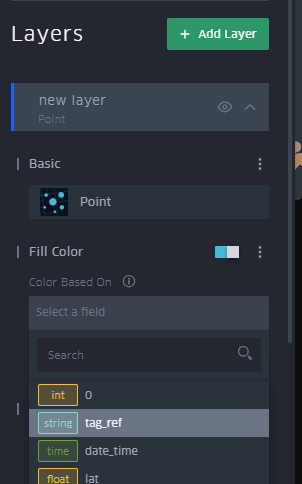

4.5 In Filters tab, click `Add Filter` select `date_time`

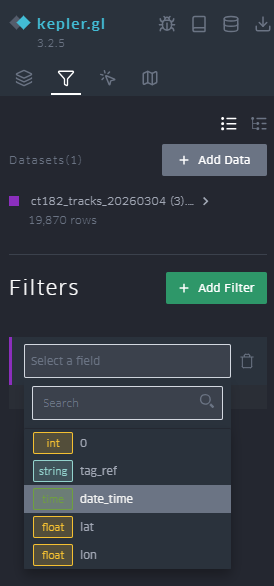

4.6 Adjust rolling window and click the play button
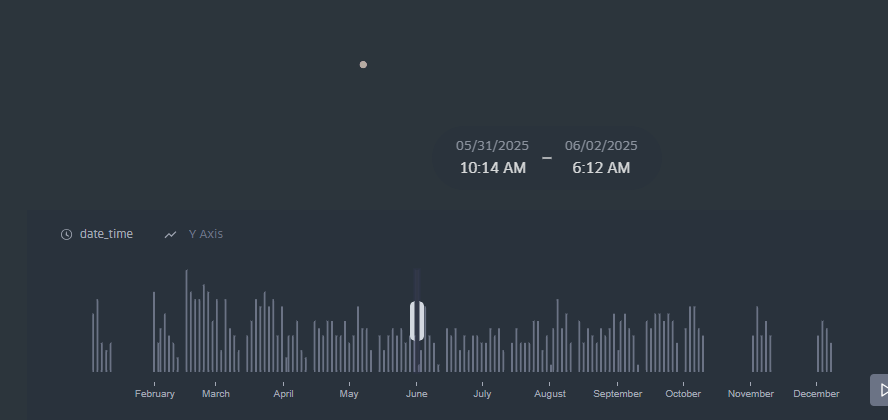

## 5. Generate smru_qc Configuration Files

### All Configuration Parameters for SSM Model and QC Process See: 

1. Node Manager Training: 

https://github.com/ocean-tracking-network/node-manager-training/blob/nrt-ArgosQC/_episodes/30_near_real_time_qc_process.md

2. ArgosQC vignette: 

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/WC_config_file.Rmd

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/SMRU_workflow.Rmd

### Required Parameters:
#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `common_name` and `species`

### Observe and Modify Configuration File(s) as Needed

- Example configuration file (json):

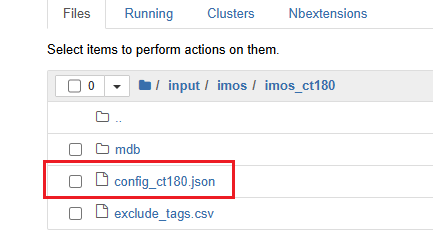


In [ ]:
# Default settings
time_step = 3
download =  False if (not user) and (not password) else True

# Campaign specific settings
common_name = 'southern elephant seal'
species = 'Mirounga leonina'
release_site = 'Kerguelen'
state_country = ' French Southern and Antarctic Lands'

output_files = aspc.create_smru_qc_config(
    program = program,
    cid = cid,
    drop_ids = exclude_tag_ref,
    otn_collection_code = otn_collection_code,
    qc_input_path = qc_input_path,
    qc_output_path=qc_output_path,
    mdb_tables_path=mdb_tables_path,
    user=user, 
    password=password, 
    time_step=time_step,
    download=download,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country
)
http://localhost:8890/notebooks/ArgosQC_SMRU_Project_Config.ipynb#

## 6. Next Step: Run ArgosQC for Configured Project

### Option 1:  `ArgosQC_SMRU` R-Notebook

- Replace config = "<smru_config_file.json>" with the above output path for `smru_qc config file`
```
library(ArgosQC)
library(pathroutr)
smru_qc(
  wd = ".",
  config = "<smru_config_file.json>"
)
```

### Option 2: In RStudio (Local or Server)

- Instructions: https://github.com/ianjonsen/ArgosQC?tab=readme-ov-file#installation

## 7. Evaluate ArgosQC Resluts

### After smru_qc is done find ssm output file in qc/\<program>/\<program>_\<cid>/

e.g. qc/imos/imos_ct182/\*ssmoutputs\*_nrt.csv

In [ ]:
subset_tags = [ 'ct182-890C-I2C-24']
tag_ssmoutput_df = aspc.extract_ssmoutput_tracks(program, cid, qc_output_path, subset_tags, verbose=verbose)


## 8. Visualize SSM Output with Raw Tracks - Helps to Verify and Improve Model Perforamce

8.1 Click the CSV button in above cell and download <cid>_ssmoutput_<yyyymmdd>.csv

8.2 Upload data `<cid>_ssmoutput_<yyyymmdd>.csv` in the same kepler.gl viewer.
    
8.3 Add a Point Layer and Fill Color by `tag_ref`
    
   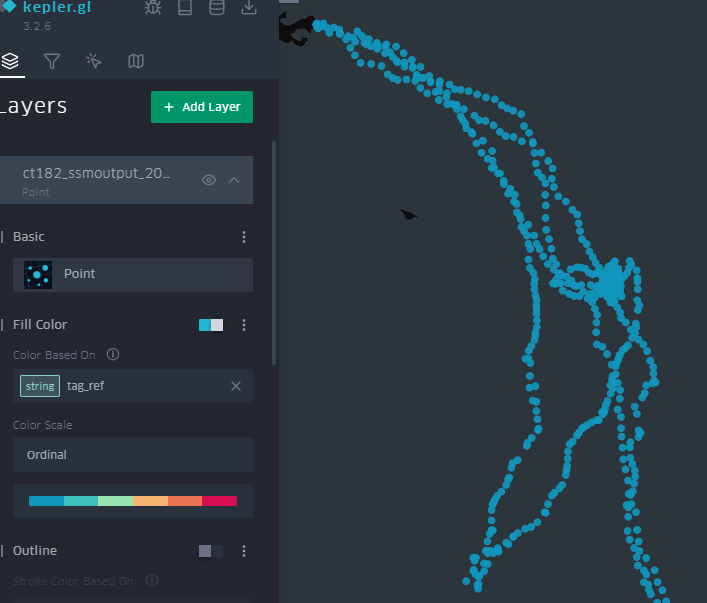
    
8.4 Toggle raw and ssmoutput layers for static observation
    
  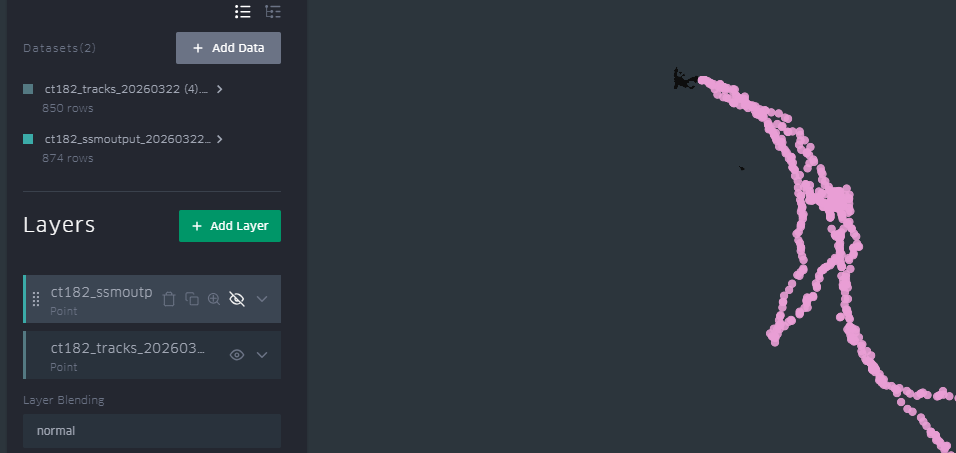
    
8.4 In Filters tab click Synced datasets and select <cid>_ssmoutput_<yyyymmdd>.csv
    
   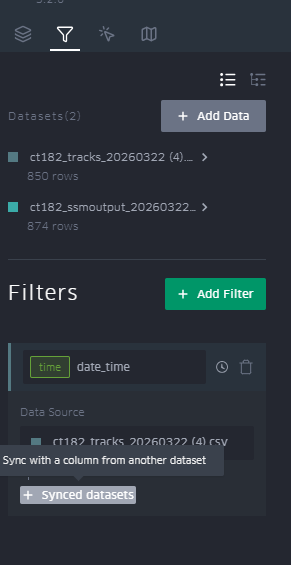
    
8.5 Adjust sliding window on the bottom and compare raw and QCed animal locations over time.
    
 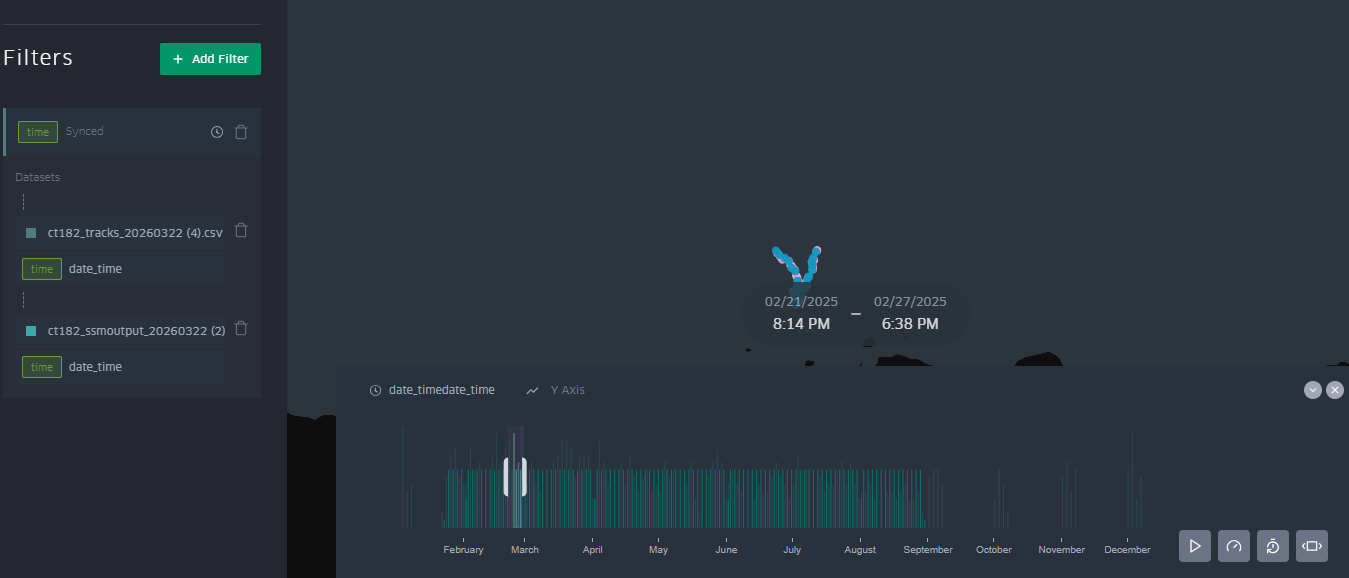